# Ocean Currents Data Export for Deck.gl

This notebook reads NetCDF files containing ocean velocity data (u, v, w components) and exports them to JSON format for deck.gl visualization.

In [2]:
# Import required libraries
import xarray as xr
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
# Load the NetCDF files
# You have separate files for U, V, and W velocities
# Available months: 199201, 199202, 199203, 199204, 199205

# Select which month to process
month = '199201'  # Change this to process different months

u_file = f'UVEL.1440x720x50.{month}.nc'
v_file = f'VVEL.1440x720x50.{month}.nc'
w_file = f'WVEL.1440x720x50.{month}.nc'

print(f"Loading data for month: {month}")
print(f"U velocity file: {u_file}")
print(f"V velocity file: {v_file}")
print(f"W velocity file: {w_file}")

# Open the datasets
ds_u = xr.open_dataset(u_file)
ds_v = xr.open_dataset(v_file)
ds_w = xr.open_dataset(w_file)

# Display dataset information from U velocity file
print("\n=== U Velocity Dataset ===")
print("Variables:", list(ds_u.data_vars))
print("Coordinates:", list(ds_u.coords))
print("Dimensions:", dict(ds_u.dims))

print("\n=== V Velocity Dataset ===")
print("Variables:", list(ds_v.data_vars))

print("\n=== W Velocity Dataset ===")
print("Variables:", list(ds_w.data_vars))

Loading data for month: 199201
U velocity file: UVEL.1440x720x50.199201.nc
V velocity file: VVEL.1440x720x50.199201.nc
W velocity file: WVEL.1440x720x50.199201.nc

=== U Velocity Dataset ===
Variables: ['UVEL']
Coordinates: ['DEPTH_T', 'LATITUDE_T', 'LONGITUDE_T', 'TIME']
Dimensions: {'DEPTH_T': 50, 'LATITUDE_T': 720, 'LONGITUDE_T': 1440, 'TIME': 1}

=== V Velocity Dataset ===
Variables: ['VVEL']

=== W Velocity Dataset ===
Variables: ['WVEL']


In [4]:
# Explore the dataset structure
print("=== Exploring U Velocity Dataset ===")
for var in ds_u.data_vars:
    print(f"\n{var}:")
    print(f"  Shape: {ds_u[var].shape}")
    print(f"  Dimensions: {ds_u[var].dims}")
    if hasattr(ds_u[var], 'long_name'):
        print(f"  Long name: {ds_u[var].long_name}")
    if hasattr(ds_u[var], 'units'):
        print(f"  Units: {ds_u[var].units}")

print("\n=== Coordinate Information ===")
for coord in ds_u.coords:
    print(f"\n{coord}:")
    print(f"  Shape: {ds_u[coord].shape}")
    print(f"  Range: [{ds_u[coord].min().values} to {ds_u[coord].max().values}]")

=== Exploring U Velocity Dataset ===

UVEL:
  Shape: (1, 50, 720, 1440)
  Dimensions: ('TIME', 'DEPTH_T', 'LATITUDE_T', 'LONGITUDE_T')
  Long name: zonal velocity
  Units: m/s

=== Coordinate Information ===

DEPTH_T:
  Shape: (50,)
  Range: [5.0 to 5906.25]

LATITUDE_T:
  Shape: (720,)
  Range: [-89.875 to 89.875]

LONGITUDE_T:
  Shape: (1440,)
  Range: [0.125 to 359.875]

TIME:
  Shape: (1,)
  Range: [1992-01-16T00:00:00.000000000 to 1992-01-16T00:00:00.000000000]


In [9]:
# Extract velocity components from separate datasets
# The variable names in each file should be consistent (likely 'UVEL', 'VVEL', 'WVEL')

# Identify the velocity variable name (usually the main data variable)
u_var_name = list(ds_u.data_vars)[0]
v_var_name = list(ds_v.data_vars)[0]
w_var_name = list(ds_w.data_vars)[0]

print(f"U variable: {u_var_name}")
print(f"V variable: {v_var_name}")
print(f"W variable: {w_var_name}")

# Select depth level and time index
# For ocean surface currents, use level 0 (surface)
# The data is 1440x720x50, suggesting: longitude x latitude x depth
depth_index = 0  # Surface level
time_index = 0   # First time step in the month

# Get dimension names
dims = list(ds_u[u_var_name].dims)
print(f"\nDimensions: {dims}")

# Extract data based on available dimensions
# Common dimension patterns: (time, depth, lat, lon) or (depth, lat, lon) or (lat, lon, depth)


u_data = ds_u[u_var_name].isel({dims[0]: time_index, dims[1]: depth_index}).values
v_data = ds_v[v_var_name].isel({dims[0]: time_index, dims[1]: depth_index}).values
w_data = ds_w[w_var_name].isel({dims[0]: time_index, dims[1]: depth_index}).values


print(f"\nU velocity shape: {u_data.shape}")
print(f"V velocity shape: {v_data.shape}")
print(f"W velocity shape: {w_data.shape}")

# Get coordinate arrays (latitude and longitude)

lat_coord = 'LATITUDE_T'
lon_coord = 'LONGITUDE_T'

lats = ds_u[lat_coord].values
lons = ds_u[lon_coord].values

print(f"\nLatitude coordinate: {lat_coord}")
print(f"Longitude coordinate: {lon_coord}")
print(f"Latitude range: [{lats.min():.2f}, {lats.max():.2f}]")
print(f"Longitude range: [{lons.min():.2f}, {lons.max():.2f}]")
print(f"Grid resolution: {lats.shape[0]} x {lons.shape[0]} points")

U variable: UVEL
V variable: VVEL
W variable: WVEL

Dimensions: ['TIME', 'DEPTH_T', 'LATITUDE_T', 'LONGITUDE_T']

U velocity shape: (720, 1440)
V velocity shape: (720, 1440)
W velocity shape: (720, 1440)

Latitude coordinate: LATITUDE_T
Longitude coordinate: LONGITUDE_T
Latitude range: [-89.88, 89.88]
Longitude range: [0.12, 359.88]
Grid resolution: 720 x 1440 points


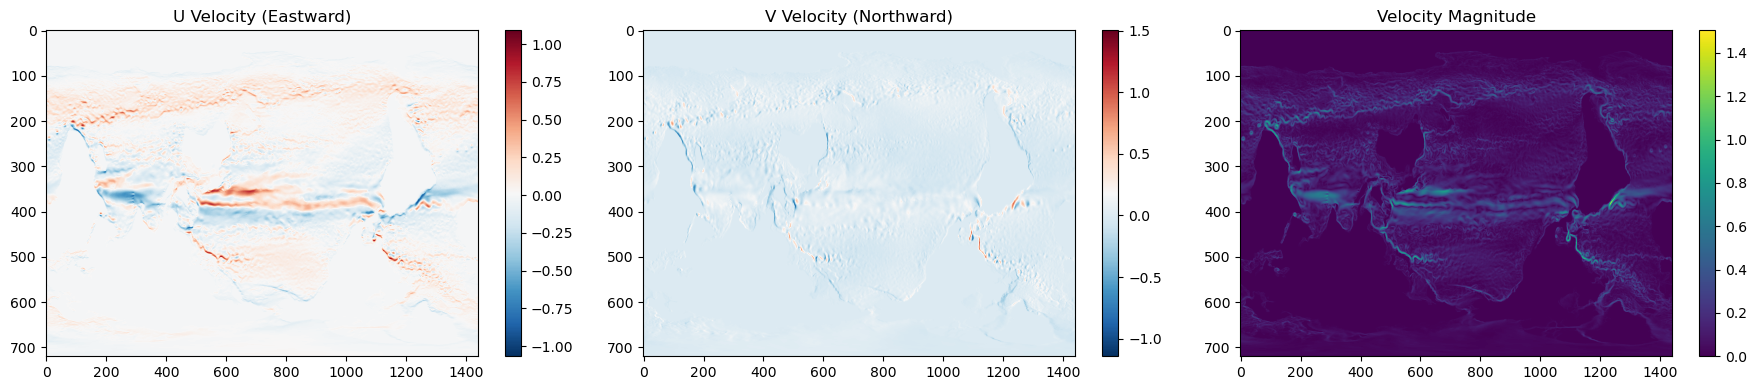

In [10]:
# Visualize the velocity field (optional)
if u_data is not None and v_data is not None:
    # Calculate velocity magnitude
    velocity_magnitude = np.sqrt(u_data**2 + v_data**2)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    # U component
    im1 = axes[0].imshow(u_data, aspect='auto', cmap='RdBu_r')
    axes[0].set_title('U Velocity (Eastward)')
    plt.colorbar(im1, ax=axes[0])
    
    # V component
    im2 = axes[1].imshow(v_data, aspect='auto', cmap='RdBu_r')
    axes[1].set_title('V Velocity (Northward)')
    plt.colorbar(im2, ax=axes[1])
    
    # Magnitude
    im3 = axes[2].imshow(velocity_magnitude, aspect='auto', cmap='viridis')
    axes[2].set_title('Velocity Magnitude')
    plt.colorbar(im3, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

In [16]:
# Option 1: Export as regular grid (image format)
# This format is efficient for deck.gl's BitmapLayer or custom shader-based rendering

def export_grid_format(u_data, v_data, w_data, lats, lons, output_file):
    """
    Export velocity data in grid format suitable for deck.gl image-based rendering.
    """
    data = {
        'bounds': {
            'minLat': float(lats.min()),
            'maxLat': float(lats.max()),
            'minLon': float(lons.min()),
            'maxLon': float(lons.max())
        },
        'dimensions': {
            'width': int(lons.shape[0]),
            'height': int(lats.shape[0])
        },
        'u': u_data.tolist(),
        'v': v_data.tolist()
    }
    
    if w_data is not None:
        data['w'] = w_data.tolist()
        
    # Convert NaN to None before dumping
    data = nan_to_none(data)
    
    with open(output_file, 'w') as f:
        json.dump(data, f)
    
    print(f"Grid format data exported to {output_file}")
    print(f"File size: {Path(output_file).stat().st_size / 1024:.2f} KB")

if u_data is not None and v_data is not None:
    export_grid_format(u_data, v_data, w_data, lats, lons, 'ocean_currents_grid.json')

Grid format data exported to ocean_currents_grid.json
File size: 50563.70 KB


In [15]:
# Option 2: Export as point cloud (particle format)
# This format works well with deck.gl's ScatterplotLayer or custom particle rendering

def nan_to_none(obj):
    """Convert NaN values to None for JSON serialization."""
    if isinstance(obj, float) and np.isnan(obj):
        return None
    elif isinstance(obj, dict):
        return {key: nan_to_none(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [nan_to_none(item) for item in obj]
    return obj

def export_particle_format(u_data, v_data, w_data, lats, lons, output_file, subsample=1):
    """
    Export velocity data as individual points/particles.
    
    Parameters:
    - subsample: Factor to reduce data size (e.g., 2 = every other point)
    """
    # Create meshgrid for lat/lon coordinates
    lon_grid, lat_grid = np.meshgrid(lons[::subsample], lats[::subsample])
    
    # Subsample velocity data
    u_sub = u_data[::subsample, ::subsample]
    v_sub = v_data[::subsample, ::subsample]
    
    # Flatten arrays
    particles = []
    for i in range(lat_grid.shape[0]):
        for j in range(lat_grid.shape[1]):
            particle = {
                'position': [float(lon_grid[i, j]), float(lat_grid[i, j])],
                'velocity': [float(u_sub[i, j]), float(v_sub[i, j])]
            }
            
            if w_data is not None:
                w_sub = w_data[::subsample, ::subsample]
                particle['velocity'].append(float(w_sub[i, j]))
            
            # Skip NaN values
            if not (np.isnan(particle['velocity'][0]) or np.isnan(particle['velocity'][1])):
                particles.append(particle)
    
    data = {
        'type': 'FeatureCollection',
        'features': [
            {
                'type': 'Feature',
                'geometry': {
                    'type': 'Point',
                    'coordinates': p['position']
                },
                'properties': {
                    'velocity': p['velocity']
                }
            }
            for p in particles
        ]
    }
    
    # Convert NaN to None before dumping
    data = nan_to_none(data)
    
    with open(output_file, 'w') as f:
        json.dump(data, f)
    
    print(f"Particle format data exported to {output_file}")
    print(f"Number of particles: {len(particles)}")
    print(f"File size: {Path(output_file).stat().st_size / 1024:.2f} KB")

if u_data is not None and v_data is not None:
    # Export with subsampling to reduce file size (adjust subsample factor as needed)
    export_particle_format(u_data, v_data, w_data, lats, lons, 
                          'ocean_currents_particles.json', subsample=2)

Particle format data exported to ocean_currents_particles.json
Number of particles: 259200
File size: 42014.46 KB


In [13]:
# Option 3: Export in a compact binary-friendly format
# This can be more efficient for large datasets

def export_compact_format(u_data, v_data, w_data, lats, lons, output_file):
    """
    Export in a compact format with flattened arrays.
    Suitable for custom deck.gl layers with efficient data transfer.
    """
    # Calculate magnitude and direction for easier rendering
    magnitude = np.sqrt(u_data**2 + v_data**2)
    direction = np.arctan2(v_data, u_data)  # in radians
    
    data = {
        'metadata': {
            'bounds': {
                'minLat': float(lats.min()),
                'maxLat': float(lats.max()),
                'minLon': float(lons.min()),
                'maxLon': float(lons.max())
            },
            'dimensions': {
                'width': int(lons.shape[0]),
                'height': int(lats.shape[0])
            },
            'statistics': {
                'maxMagnitude': float(np.nanmax(magnitude)),
                'minMagnitude': float(np.nanmin(magnitude)),
                'meanMagnitude': float(np.nanmean(magnitude))
            }
        },
        'data': {
            'u': u_data.flatten().tolist(),
            'v': v_data.flatten().tolist(),
            'magnitude': magnitude.flatten().tolist(),
            'direction': direction.flatten().tolist()
        }
    }
    
    if w_data is not None:
        data['data']['w'] = w_data.flatten().tolist()
    
    with open(output_file, 'w') as f:
        json.dump(data, f)
    
    print(f"Compact format data exported to {output_file}")
    print(f"File size: {Path(output_file).stat().st_size / 1024:.2f} KB")

if u_data is not None and v_data is not None:
    export_compact_format(u_data, v_data, w_data, lats, lons, 'ocean_currents_compact.json')

Compact format data exported to ocean_currents_compact.json
File size: 81501.58 KB


In [14]:
# Close all datasets
ds_u.close()
ds_v.close()
ds_w.close()
print("All datasets closed successfully.")

All datasets closed successfully.


## Usage in Deck.gl

### For Grid Format:
```javascript
// Load the grid data
const data = await fetch('ocean_currents_grid.json').then(r => r.json());

// Use with a custom layer or texture-based rendering
// You can create particles from this grid in your shader
```

### For Particle Format (GeoJSON):
```javascript
import {ScatterplotLayer} from '@deck.gl/layers';

const data = await fetch('ocean_currents_particles.json').then(r => r.json());

const layer = new ScatterplotLayer({
  id: 'ocean-currents',
  data: data.features,
  getPosition: d => d.geometry.coordinates,
  getRadius: 1000,
  getFillColor: d => {
    const [u, v] = d.properties.velocity;
    const magnitude = Math.sqrt(u*u + v*v);
    return [magnitude * 10, 0, 255 - magnitude * 10];
  }
});
```

### For Compact Format:
```javascript
const data = await fetch('ocean_currents_compact.json').then(r => r.json());

// Use the flattened arrays for efficient GPU-based particle simulation
// Access data.data.u, data.data.v, data.data.magnitude, data.data.direction
```